# Homework 1 - Task 1: Denoising (Google Colab)

Notebook pronto per Google Colab.

**Istruzioni:**
1. Esegui le celle in ordine.
2. Quando richiesto, carica `IPPy.zip` e `0.png`.

Questo task NON richiede astra-toolbox.

## 1. Dipendenze

In [5]:
# Dipendenze (torch e' gia' su Colab; installiamo solo scikit-image per le metriche)
!pip install scikit-image -q
print("ok")

ok


## 2. Carica IPPy.zip e 0.png

In [6]:
from google.colab import files
import zipfile, os

print('Carica IPPy.zip e 0.png ...')
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname) as z:
            z.extractall('.')
        print('Estratto:', fname)

# Se lo zip conteneva un contenitore tipo IPPy-main/IPPy, sistemiamo automaticamente
if not os.path.isdir('IPPy'):
    for root, dirs, files_ in os.walk('.'):
        if 'IPPy' in dirs and os.path.isfile(os.path.join(root,'IPPy','__init__.py')):
            import shutil
            shutil.move(os.path.join(root,'IPPy'), 'IPPy')
            print('Spostata IPPy da', root)
            break

print('Contenuto:', os.listdir('.'))
assert os.path.isdir('IPPy'), 'Manca la cartella IPPy/ (carica IPPy.zip)'
assert os.path.isfile('0.png'), 'Manca 0.png'

Carica IPPy.zip e 0.png ...


Saving 0.png to 0 (2).png
Saving IPPy.zip to IPPy (1).zip
Estratto: IPPy (1).zip
Contenuto: ['.config', '0 (2).png', '0.png', 'IPPy (1).zip', 'IPPy', 'IPPy.zip', '0 (1).png', 'sample_data']


## 3. Test problem

In [7]:
import math
import torch
import matplotlib.pyplot as plt

from IPPy import utilities, operators, solvers
from IPPy.utilities import load_image, save_image, normalize
from IPPy.utilities.metrics import PSNR, SSIM, RE

torch.manual_seed(42)
print("Device:", utilities.get_device())

# 1. Immagine
x_true = load_image('0.png')
print("GT shape:", list(x_true.shape))

# 2. Test problem: K = Identita', rumore gaussiano
K = operators.Identity(img_shape=x_true.shape[-2:])
noise_level = 0.05                      # <-- varia il livello di rumore (0.01, 0.02, 0.05)
y_delta = K(x_true) + noise_level * torch.randn_like(x_true) # immagine rumorosa con rumero gaussiano
delta = noise_level * math.sqrt(x_true.numel())# stima dell'entità del rumore
print("delta =", round(delta,3), "| PSNR noisy =", round(PSNR(y_delta,x_true),2), "dB")

Device: cpu
GT shape: [1, 1, 256, 256]
delta = 12.8 | PSNR noisy = 25.97 dB


## 4. Solver

In [8]:
# 3. Definiamo i tre solver
grad_op = operators.Gradient(x_true.shape[-2:])#calcola quanto cambia il valore da un pixel al suo vicino
def solve_tikhonov(lmbda, maxiter=200, step=0.1):# step : sposto di un passetto la soluzione verso la riduzione dell'errore
    x = y_delta.clone(); hist={"PSNR":[],"SSIM":[],"res":[]}
    for _ in range(maxiter):#passo di discesa del gradiente
        x = x - step*(K.T(K(x)-y_delta) + lmbda*grad_op.T(grad_op(x)))
        x = torch.clamp(x,0,1)#forzo i valori dei pixel a restare tra 0 e 1
        hist["PSNR"].append(PSNR(x,x_true)); hist["SSIM"].append(SSIM(x,x_true))
        hist["res"].append(torch.norm((K(x)-y_delta).flatten()).item())
    return x.detach(), hist

cp = solvers.ChambollePockTpVUnconstrained(K)#Crea il solver Chambolle-Pock della libreria IPPy. Perché TV e TpV usano la norma L1, che non è differenziabile nel punto zero
def solve_cp(lmbda, p, maxiter=200):#Una sola funzione per entrambi TV e TpV: la differenza è solo il parametro p.
    x,info = cp(y_delta, x_true=x_true, starting_point=torch.zeros_like(x_true),
                lmbda=lmbda, maxiter=maxiter, p=p, verbose=False)
    return x.detach(), info

## 5. Grid search

In [9]:
# 4. Grid search + due criteri di lambda,prova tanti valori di λ per ogni metodo e seleziona i migliori secondo i due criteri richiesti dall'homework.
 #non sappiamo a priori il λ giusto, quindi li proviamo tutti e vediamo quale funziona meglio.
lambdas = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]
tau = 1.01
def pc(info): return info["PSNR"] if isinstance(info["PSNR"],list) else info["PSNR"][:,0].cpu().numpy().tolist() #servono per estrarre i dati
def sc(info): return info["SSIM"] if isinstance(info["SSIM"],list) else info["SSIM"][:,0].cpu().numpy().tolist()
def res(info): return info["res"][-1] if "res" in info else math.sqrt(abs(info["residues"][-1,0].item()))
def grid(runner): #grid riceve un runner (un metodo da eseguire, es. Tikhonov) e cicla su tutti i λ della lista.
    best={"psnr":-1}; dp={"gap":float("inf")}
    for lam in lambdas:
        x,info=runner(lam); pv=max(pc(info)); r=res(info)
        if pv>best["psnr"]: best={"psnr":pv,"lam":lam,"x":x,"info":info} #salviamo il best psnr
        g=abs(r-tau*delta)
        if g<dp["gap"]: dp={"gap":g,"lam":lam,"x":x,"info":info,"psnr":pv}#"la soluzione buona è quella il cui residuo∥Kx−y∥ è circa uguale al rumore atteso, delta è la stima del rumore
    return best,dp
print("Grid search...")
tk,tk_dp = grid(lambda l: solve_tikhonov(l)); print("Tikhonov done")
tv,tv_dp = grid(lambda l: solve_cp(l,1.0));   print("TV done")
tp,tp_dp = grid(lambda l: solve_cp(l,0.5));   print("TpV done")

Grid search...
Tikhonov done
TV done
TpV done


## 6. Tabella

In [10]:
# 5. Tabella
def rowf(n,d): return f"{n:<22} | {d['lam']:<8.4f} | {d['psnr']:<8.2f} | {max(sc(d['info'])):<6.4f}"
print("="*56)
print(f"{'METODO (criterio)':<22} | {'LAMBDA':<8} | {'PSNR':<8} | SSIM"); print("-"*56)
print(f"{'Noisy':<22} | {'-':<8} | {PSNR(y_delta,x_true):<8.2f} | {SSIM(y_delta,x_true):.4f}")
print(rowf("Tikhonov (best)",tk)); print(rowf("Tikhonov (DP)",tk_dp))
print(rowf("TV p=1 (best)",tv));   print(rowf("TV p=1 (DP)",tv_dp))
print(rowf("TpV p=.5 (best)",tp)); print(rowf("TpV p=.5 (DP)",tp_dp))
print("="*56)

METODO (criterio)      | LAMBDA   | PSNR     | SSIM
--------------------------------------------------------
Noisy                  | -        | 25.97    | 0.6615
Tikhonov (best)        | 0.0500   | 27.41    | 0.7154
Tikhonov (DP)          | 0.0500   | 27.41    | 0.7154
TV p=1 (best)          | 0.0500   | 28.05    | 0.8344
TV p=1 (DP)            | 0.0005   | 26.07    | 0.7497
TpV p=.5 (best)        | 0.0100   | 28.73    | 0.8059
TpV p=.5 (DP)          | 0.0500   | 27.04    | 0.7951


## 7. Visualizzazione

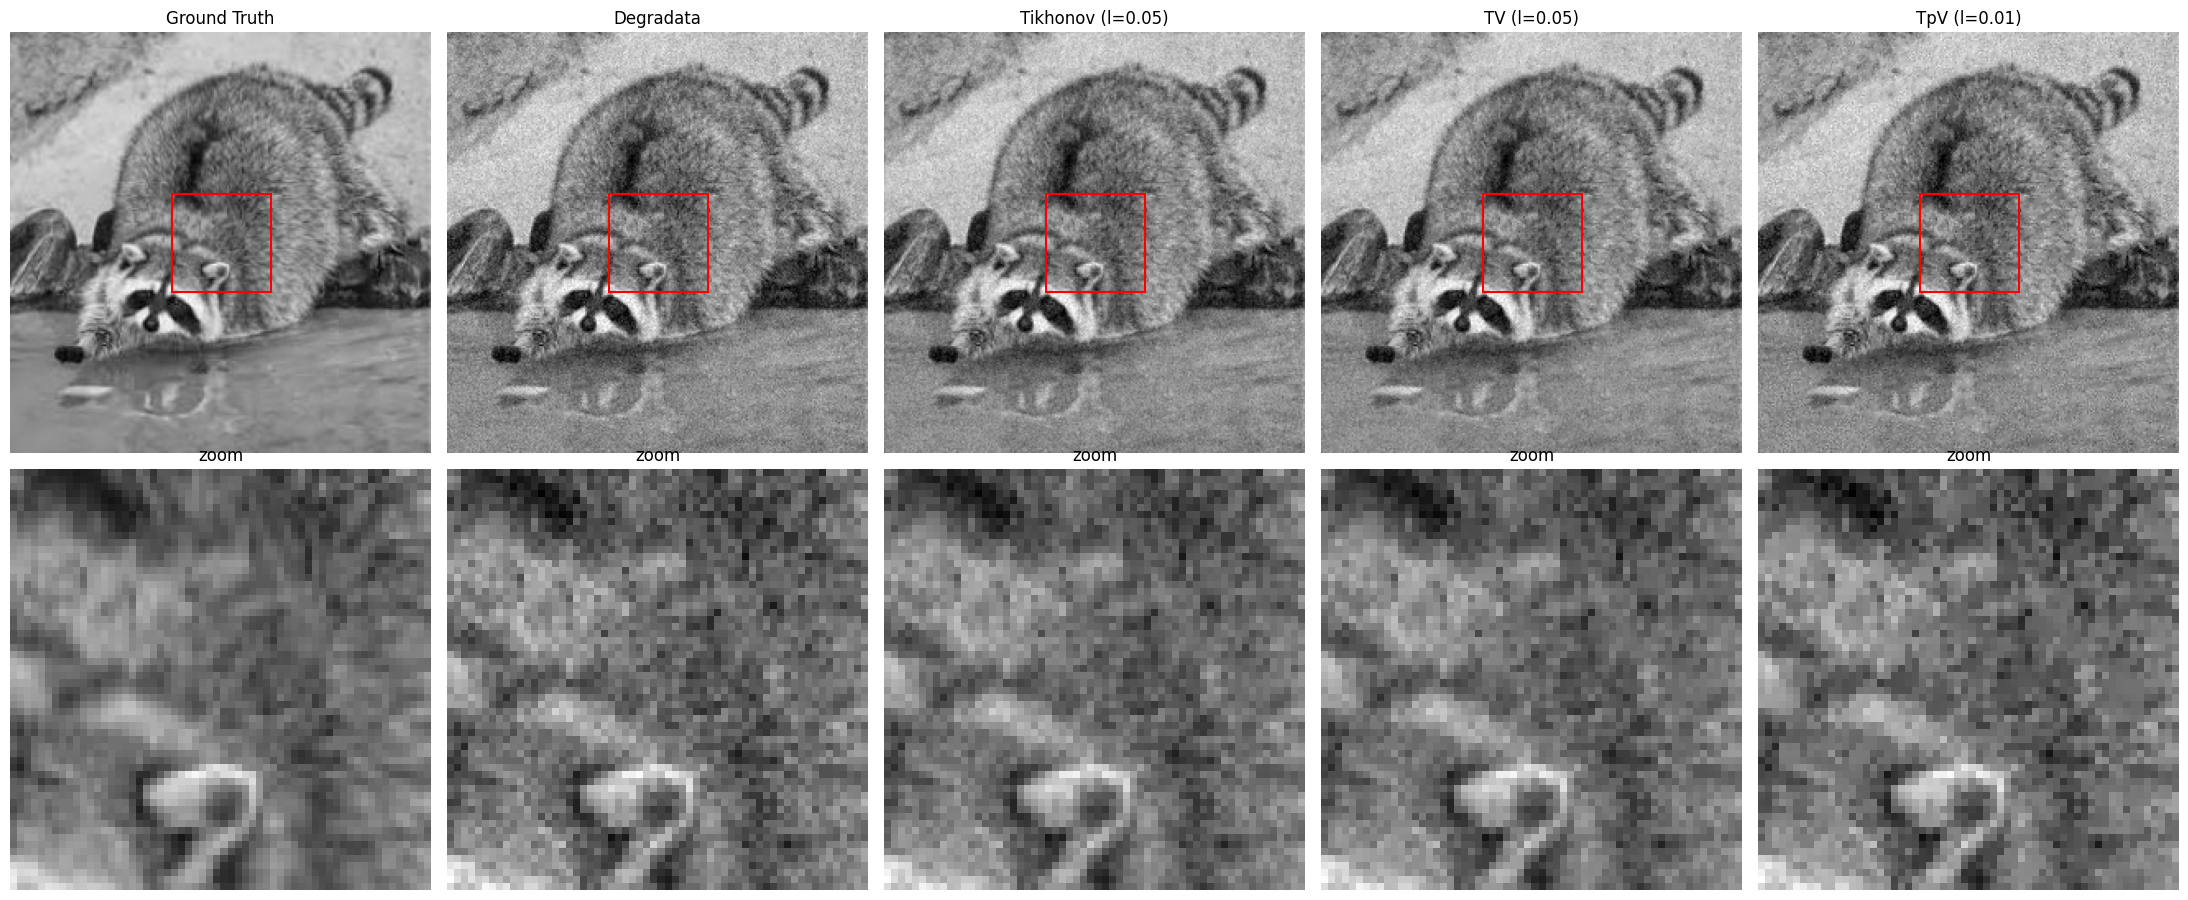

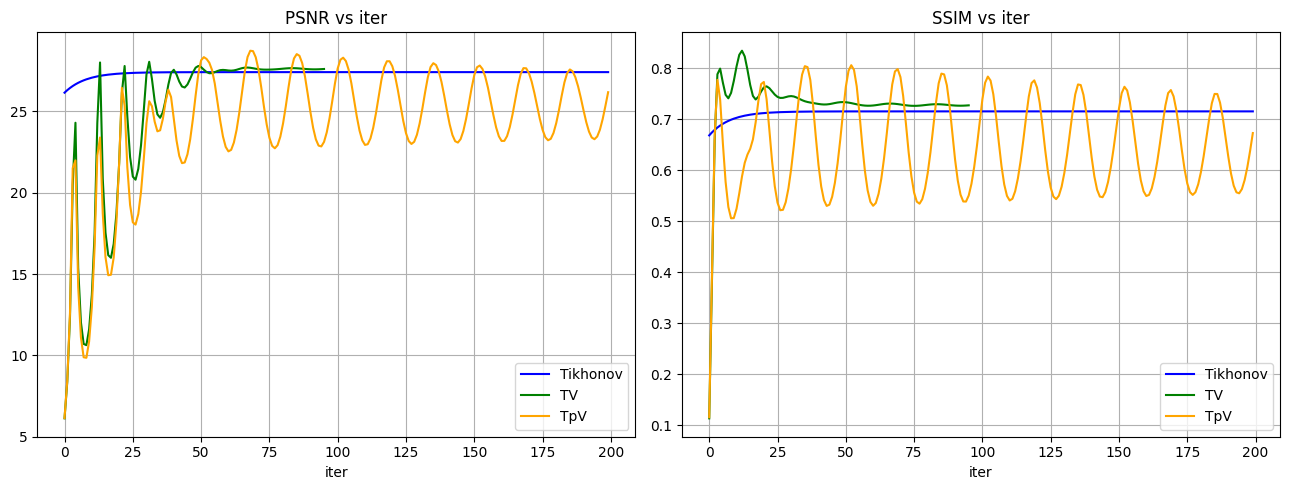

In [11]:
# 6. Immagini + zoom  e  7. Metriche per iterazione
to_np=lambda t:t.detach()[0,0].cpu().numpy() #Una funzione-aiuto che converte un tensore PyTorch in un array disegnabile
imgs=[x_true,y_delta,tk["x"],tv["x"],tp["x"]]
titles=["Ground Truth","Degradata",f"Tikhonov (l={tk['lam']})",f"TV (l={tv['lam']})",f"TpV (l={tp['lam']})"]
H=x_true.shape[-1]; a,b=H//2-30,H//2+30 #Definisce il riquadro di zoom
fig,ax=plt.subplots(2,5,figsize=(22,9))
for i,(im,ti) in enumerate(zip(imgs,titles)): #disposizione delle immgini
    arr=to_np(im)
    ax[0,i].imshow(arr,cmap='gray',vmin=0,vmax=1); ax[0,i].set_title(ti); ax[0,i].axis('off')
    ax[0,i].add_patch(plt.Rectangle((a,a),b-a,b-a,edgecolor='red',facecolor='none',lw=1.5))
    ax[1,i].imshow(arr[a:b,a:b],cmap='gray',vmin=0,vmax=1); ax[1,i].set_title('zoom'); ax[1,i].axis('off')
plt.tight_layout(); plt.show()

fig,ax=plt.subplots(1,2,figsize=(13,5))
for c,lab,col in [(tk,'Tikhonov','blue'),(tv,'TV','green'),(tp,'TpV','orange')]:
    ax[0].plot(pc(c['info']),label=lab,color=col); ax[1].plot(sc(c['info']),label=lab,color=col)
ax[0].set_title('PSNR vs iter'); ax[0].set_xlabel('iter'); ax[0].legend(); ax[0].grid(True)
ax[1].set_title('SSIM vs iter'); ax[1].set_xlabel('iter'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()


#Una curva che sale e poi si stabilizza = il metodo ha trovato la soluzione e si è fermato lì.
#Una curva che sale e poi scende = il metodo ha superato l'ottimo e sta peggiorando
#Curve irregolari/oscillanti = instabilità

